In [1]:
import os
import gc
import ast
import copy
import time
import random
import numpy as np
import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as torchdata

from Model.MENDR.MENDREncoder import MENDREncoder, WaveletEncoderDecoder
from Model.MENDR.MENDRContextualizer import MENDRContextualizer
from Model.MENDR.MENDRTrainer import MENDRTrainer
from Model.MENDR.mAtt.optimizer import MixOptimizer

from dataset import WaveletFinetuningDataset
from torch_geometric.loader import DataLoader
from sklearn.metrics import balanced_accuracy_score
import optuna
from optuna.trial import TrialState

/home/hice1/mchen439/scratch/miniconda3/envs/Wavelet/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load Dataset
print("*" * 50)
train_dataset = WaveletFinetuningDataset(root="/home/hice1/mchen439/scratch/downstreamTaskData/train")
print("Dataset Loaded. Length of Train Dataset: ", len(train_dataset))
eval_dataset = WaveletFinetuningDataset(root="/home/hice1/mchen439/scratch/downstreamTaskData/eval")
print("Dataset Loaded. Length of Validation Dataset: ", len(eval_dataset))


**************************************************
Loading 2130 folders


100%|██████████| 2130/2130 [02:01<00:00, 17.56it/s]


Dataset Loaded. Length of Train Dataset:  44854
Loading 253 folders


100%|██████████| 253/253 [00:11<00:00, 21.65it/s]

Dataset Loaded. Length of Validation Dataset:  5101


In [5]:
### Seed ###
torch.cuda.empty_cache()
random.seed(42)
os.environ['PYTHONHASHSEED'] = str(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed(42)
torch.cuda.manual_seed_all(42)
## CUDNN ##
torch.backends.cudnn.enabled = True
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

In [9]:
BANDS = ['delta', 'theta', 'alpha', 'beta', 'gamma']
train_loader = DataLoader(train_dataset, batch_size=256, num_workers=2, shuffle=True)
eval_loader = DataLoader(eval_dataset, batch_size=256, num_workers=2, shuffle=False)
print(len(train_loader), len(eval_loader))

def _std_norm(x):
	mean = torch.mean(x, dim=(0, 1), keepdim=True)
	std = torch.std(x, dim=(0, 1), keepdim=True)
	x = (x - mean) / std
	return x

176 20


In [188]:
### Model ###
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
encoder = MENDREncoder(device=device)
contextualizer = MENDRContextualizer(device=device)

for param in encoder.parameters():
    param.requires_grad = False

for param in contextualizer.parameters():
    param.requires_grad = False

encoder.load_state_dict(torch.load("checkpoint/batch_size256_4epochs/encoder_weights.pth"))
contextualizer.load_state_dict(torch.load("checkpoint/batch_size256_4epochs/contextualizer_weights.pth"))

<All keys matched successfully>

In [236]:
pbar = tqdm.trange(len(train_loader), desc="Training")
data_iterator = iter(train_loader)
balanced_accuracies = []

for iteration in pbar:
    data = next(data_iterator)

    for key, value in data.items():
        if isinstance(value, torch.Tensor):
            # Perform batch normalization across channels 
            data[key] = _std_norm(value.float().to(device))

    relevant_bands = [data['delta'].float().to(device),
                        data['theta'].float().to(device),
                        data['alpha'].float().to(device),
                        data['beta'].float().to(device),
                        data['gamma'].float().to(device)]

    inputs = dict(zip(BANDS, relevant_bands))

    with torch.no_grad():
        encoder_outputs = encoder(data['graph'], inputs)
        combined_r2e_output, combined_manifold_output, wavelet_r2e_output, wavelet_manifold_output = contextualizer(encoder_outputs)

    embed_cat = [combined_r2e_output]
    for band, embedding in wavelet_r2e_output.items():
        embed_cat.append(embedding)
    embed_cat = torch.cat(embed_cat, dim=1)

    print(embed_cat)
    break



Training:   0%|          | 0/176 [00:11<?, ?it/s]

tensor([[ 0.7465, -0.1909,  2.0535,  ..., -0.2517, -0.0762, -1.3654],
        [ 1.3912, -0.9031,  1.7637,  ..., -0.6447, -0.3857, -2.3168],
        [ 1.1263, -0.9436,  1.5299,  ...,  0.2731,  1.0575, -1.3972],
        ...,
        [ 0.1964, -0.4559,  0.7070,  ..., -0.1791, -0.1294, -0.7206],
        [ 0.5894, -1.7407,  2.4217,  ..., -1.0648,  0.1407, -1.3102],
        [ 0.9128,  0.2332,  1.3479,  ..., -2.0609, -1.0882, -1.8759]],
       device='cuda:0')


In [237]:
print(data['graph'].y)

tensor([0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
        0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1,
        0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0,
        0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0,
        0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0,
        0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0,
        0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1,
        1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1,
        1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0,
        1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1])


In [241]:
import umap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.manifold import Isomap, LocallyLinearEmbedding, SpectralEmbedding, MDS
from sklearn.metrics import accuracy_score

In [272]:
#reducer = MDS()
#reducer = SpectralEmbedding()
reducer = LocallyLinearEmbedding(method='ltsa', eigen_solver='dense', n_components=5)
#reduer = Isomap()
#reducer = umap.UMAP()

Text(0.5, 1.0, 'UMAP projection of batch delta of wavelet encoding')

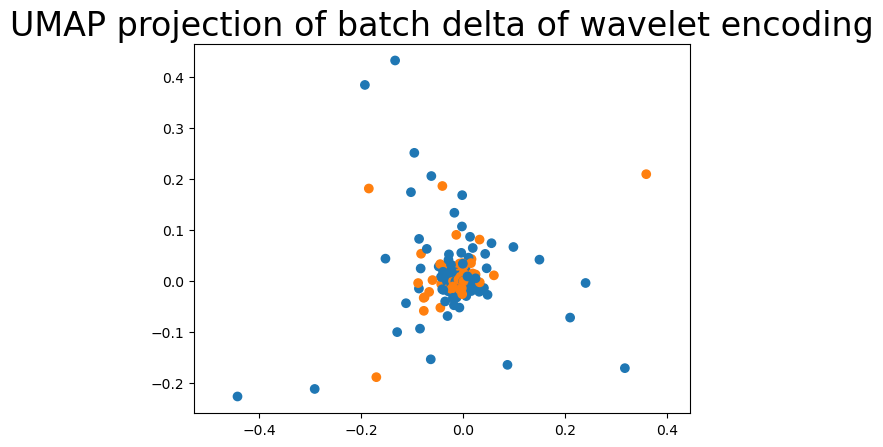

In [273]:
embedding = reducer.fit_transform(embed_cat.cpu().numpy()[:, :95], data['graph'].y)
plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=[sns.color_palette()[x] for x in data['graph'].y])
plt.gca().set_aspect('equal', 'datalim')
plt.title('UMAP projection of batch delta of wavelet encoding', fontsize=24)

Text(0.5, 1.0, 'UMAP projection of batch theta')

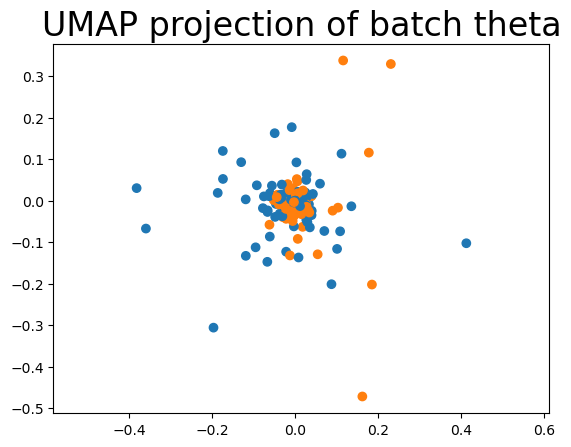

In [274]:
embedding = reducer.fit_transform(embed_cat.cpu().numpy()[:, 95:190])
plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=[sns.color_palette()[x] for x in data['graph'].y])
plt.gca().set_aspect('equal', 'datalim')
plt.title('UMAP projection of batch theta', fontsize=24)

Text(0.5, 1.0, 'UMAP projection of batch alpha')

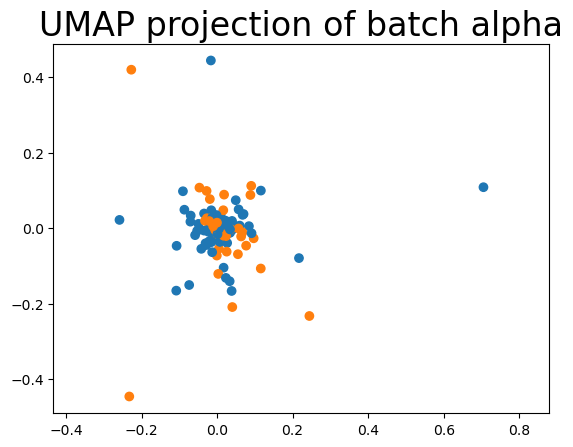

In [275]:
embedding = reducer.fit_transform(embed_cat.cpu().numpy()[:, 190:285])
plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=[sns.color_palette()[x] for x in data['graph'].y])
plt.gca().set_aspect('equal', 'datalim')
plt.title('UMAP projection of batch alpha', fontsize=24)

In [276]:
# Create an SVM classifier
clf = SVC(kernel='rbf')

# Fit the classifier to the training data
clf.fit(embedding, data['graph'].y)

# Predict on the test set
y_pred = clf.predict(embedding)

# Calculate accuracy
accuracy = accuracy_score(y_pred, data['graph'].y)
print(f"Accuracy: {accuracy}")

Accuracy: 0.625


Text(0.5, 1.0, 'UMAP projection of batch beta')

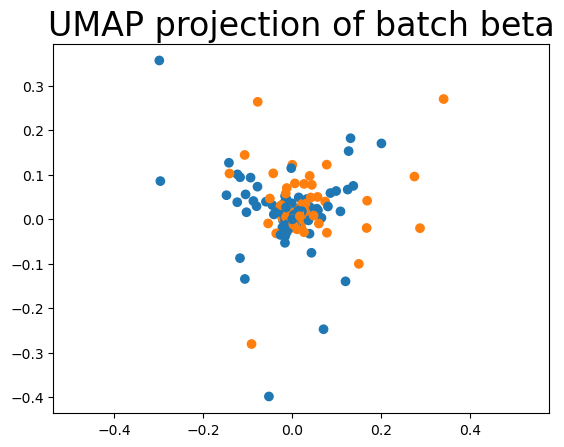

In [277]:
embedding = reducer.fit_transform(embed_cat.cpu().numpy()[:, 285:380])
plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=[sns.color_palette()[x] for x in data['graph'].y])
plt.gca().set_aspect('equal', 'datalim')
plt.title('UMAP projection of batch beta', fontsize=24)

Text(0.5, 1.0, 'UMAP projection of batch gamma')

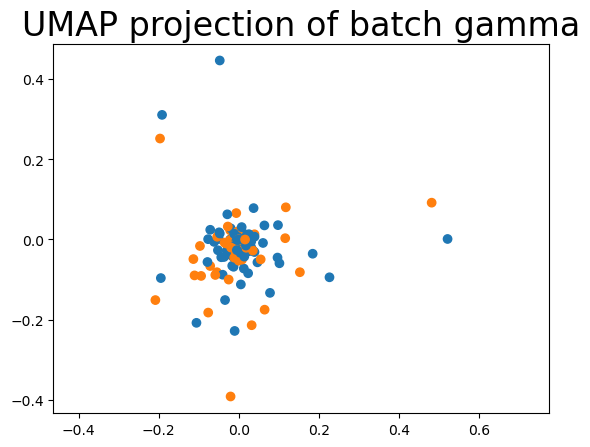

In [285]:
embedding = reducer.fit_transform(embed_cat.cpu().numpy()[:, 380:475])
plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=[sns.color_palette()[x] for x in data['graph'].y])
plt.gca().set_aspect('equal', 'datalim')
plt.title('UMAP projection of batch gamma', fontsize=24)

Text(0.5, 1.0, 'UMAP projection of batch whole signal')

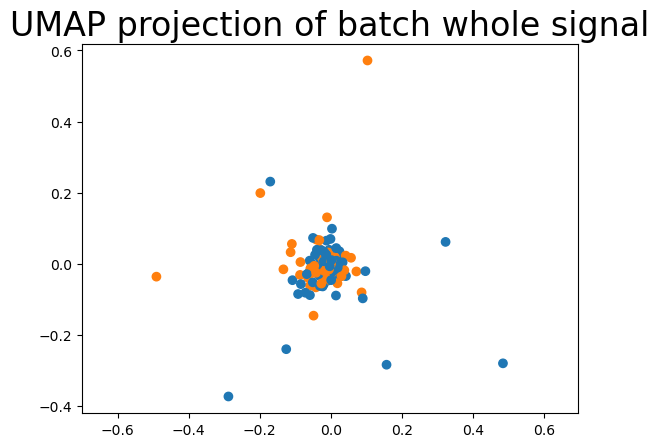

In [284]:
embedding = reducer.fit_transform(embed_cat.cpu().numpy()[:, 475:])
plt.scatter(
    embedding[:, 4],
    embedding[:, 0],
    c=[sns.color_palette()[x] for x in data['graph'].y])
plt.gca().set_aspect('equal', 'datalim')
plt.title('UMAP projection of batch whole signal', fontsize=24)

In [280]:
print(embedding.shape)

(256, 5)
